<a href="https://colab.research.google.com/github/reenasharon05/TCSiON-Course/blob/main/data_correction_tcsiON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# modules we'll use
import pandas as pd
import numpy as np

# read in all our data
df = pd.read_csv('/content/gdpWorld.csv')

# set seed for reproducibility
np.random.seed(0)

In [ ]:
# look at the first five rows of the  df data file.
# I can see a handful of missing data already!
df.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,"48,0","0,00","23,06","163,07",700.0,"36,0","3,2","12,13","0,22","87,65",1,"46,6","20,34","0,38","0,24","0,38"
1,Albania,EASTERN EUROPE,3581655,28748,"124,6","1,26","-4,93","21,52",4500.0,"86,5","71,2","21,09","4,42","74,49",3,"15,11","5,22","0,232","0,188","0,579"
2,Algeria,NORTHERN AFRICA,32930091,2381740,"13,8","0,04","-0,39",31,6000.0,"70,0","78,1","3,22","0,25","96,53",1,"17,14","4,61","0,101","0,6","0,298"
3,American Samoa,OCEANIA,57794,199,"290,4","58,29","-20,71","9,27",8000.0,"97,0","259,5",10,15,75,2,"22,46","3,27",NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,"152,1","0,00","6,6","4,05",19000.0,"100,0","497,2","2,22",0,"97,78",3,"8,71","6,25",NaN,NaN,NaN


In [ ]:
# get the number of missing data points per column
missing_values_count = df.isnull().sum()

# look at the # of missing points in the first ten columns
missing_values_count[0:10]

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          3
Infant mortality (per 1000 births)     3
GDP ($ per capita)                     1
Literacy (%)                          18
dtype: int64

In [ ]:
# how many total missing values do we have?
total_cells = np.product(df.shape)
total_missing = missing_values_count.sum()

# percent of data that is missing
percent_missing = (total_missing/total_cells) * 100
print(percent_missing)

2.4229074889867843


In [ ]:
# look at the # of missing points in the first ten columns
missing_values_count[0:10]

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          3
Infant mortality (per 1000 births)     3
GDP ($ per capita)                     1
Literacy (%)                          18
dtype: int64

In [ ]:
# remove all the rows that contain a missing value
#df.dropna()

In [ ]:
# remove all columns with at least one missing value
columns_with_na_dropped = df.dropna(axis=1)
columns_with_na_dropped.head()


,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio)
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,"48,0","0,00"
1,Albania,EASTERN EUROPE,3581655,28748,"124,6","1,26"
2,Algeria,NORTHERN AFRICA,32930091,2381740,"13,8","0,04"
3,American Samoa,OCEANIA,57794,199,"290,4","58,29"
4,Andorra,WESTERN EUROPE,71201,468,"152,1","0,00"


In [ ]:
# just how much data did we lose?
print("Columns in original dataset: %d \n" % df.shape[1])
print("Columns with na's dropped: %d" % columns_with_na_dropped.shape[1])

Columns in original dataset: 20 

Columns with na's dropped: 6


In [ ]:
# get a small subset of the NFL dataset
subset_df = df.loc[:, 'GDP ($ per capita)':'Service'].head()
subset_df

,GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,700.0,"36,0","3,2","12,13","0,22","87,65",1,"46,6","20,34","0,38","0,24","0,38"
1,4500.0,"86,5","71,2","21,09","4,42","74,49",3,"15,11","5,22","0,232","0,188","0,579"
2,6000.0,"70,0","78,1","3,22","0,25","96,53",1,"17,14","4,61","0,101","0,6","0,298"
3,8000.0,"97,0","259,5",10,15,75,2,"22,46","3,27",NaN,NaN,NaN
4,19000.0,"100,0","497,2","2,22",0,"97,78",3,"8,71","6,25",NaN,NaN,NaN


In [ ]:
# replace all NA's the value that comes directly after it in the same column,
# then replace all the remaining na's with 0
subset_df.fillna(method='bfill', axis=0).fillna(0)


,GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,700.0,"36,0","3,2","12,13","0,22","87,65",1,"46,6","20,34","0,38","0,24","0,38"
1,4500.0,"86,5","71,2","21,09","4,42","74,49",3,"15,11","5,22","0,232","0,188","0,579"
2,6000.0,"70,0","78,1","3,22","0,25","96,53",1,"17,14","4,61","0,101","0,6","0,298"
3,8000.0,"97,0","259,5",10,15,75,2,"22,46","3,27",0,0,0
4,19000.0,"100,0","497,2","2,22",0,"97,78",3,"8,71","6,25",0,0,0


In [ ]:
import numpy as np

def out_iqr(s, k=1.5, return_thresholds=False):
    """
    Return a boolean mask of outliers for a series
    using interquartile range, works column-wise.
    param k:
        some cutoff to multiply by the iqr
    :type k: ``float``
    param return_thresholds:
        True returns the lower and upper bounds, good for plotting.
        False returns the masked array
    :type return_thresholds: ``bool``
    """
    # Exclude non-numeric values
    numeric_values = pd.to_numeric(s, errors='coerce')

    # Calculate interquartile range
    q25, q75 = np.percentile(numeric_values.dropna(), 25), np.percentile(numeric_values.dropna(), 75)
    iqr = q75 - q25

    # Calculate the outlier cutoff
    cut_off = iqr * k
    lower, upper = q25 - cut_off, q75 + cut_off

    if return_thresholds:
        return lower, upper
    else: # Identify outliers
        return [True if pd.notna(x) and (x < lower or x > upper) else False for x in s]


#**EDA (inspection, data profiling, visualizations)**

In [ ]:
# Input the dataset
df1 = pd.read_csv('/content/gdpWorld.csv')
df1.head(5)

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,"48,0","0,00","23,06","163,07",700.0,"36,0","3,2","12,13","0,22","87,65",1,"46,6","20,34","0,38","0,24","0,38"
1,Albania,EASTERN EUROPE,3581655,28748,"124,6","1,26","-4,93","21,52",4500.0,"86,5","71,2","21,09","4,42","74,49",3,"15,11","5,22","0,232","0,188","0,579"
2,Algeria,NORTHERN AFRICA,32930091,2381740,"13,8","0,04","-0,39",31,6000.0,"70,0","78,1","3,22","0,25","96,53",1,"17,14","4,61","0,101","0,6","0,298"
3,American Samoa,OCEANIA,57794,199,"290,4","58,29","-20,71","9,27",8000.0,"97,0","259,5",10,15,75,2,"22,46","3,27",NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,"152,1","0,00","6,6","4,05",19000.0,"100,0","497,2","2,22",0,"97,78",3,"8,71","6,25",NaN,NaN,NaN


In [ ]:
#Check number of rows and columns, type of each columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             227 non-null    object 
 1   Region                              227 non-null    object 
 2   Population                          227 non-null    int64  
 3   Area (sq. mi.)                      227 non-null    int64  
 4   Pop. Density (per sq. mi.)          227 non-null    object 
 5   Coastline (coast/area ratio)        227 non-null    object 
 6   Net migration                       224 non-null    object 
 7   Infant mortality (per 1000 births)  224 non-null    object 
 8   GDP ($ per capita)                  226 non-null    float64
 9   Literacy (%)                        209 non-null    object 
 10  Phones (per 1000)                   223 non-null    object 
 11  Arable (%)                          225 non-n

In [ ]:
# Understanding the numeric fields
df.describe()

,Population,Area (sq. mi.),GDP ($ per capita)
count,2.270000e+02,2.270000e+02,226.000000
mean,2.874028e+07,5.982270e+05,9689.823009
std,1.178913e+08,1.790282e+06,10049.138513
min,7.026000e+03,2.000000e+00,500.000000
25%,4.376240e+05,4.647500e+03,1900.000000
50%,4.786994e+06,8.660000e+04,5550.000000
75%,1.749777e+07,4.418110e+05,15700.000000
max,1.313974e+09,1.707520e+07,55100.000000


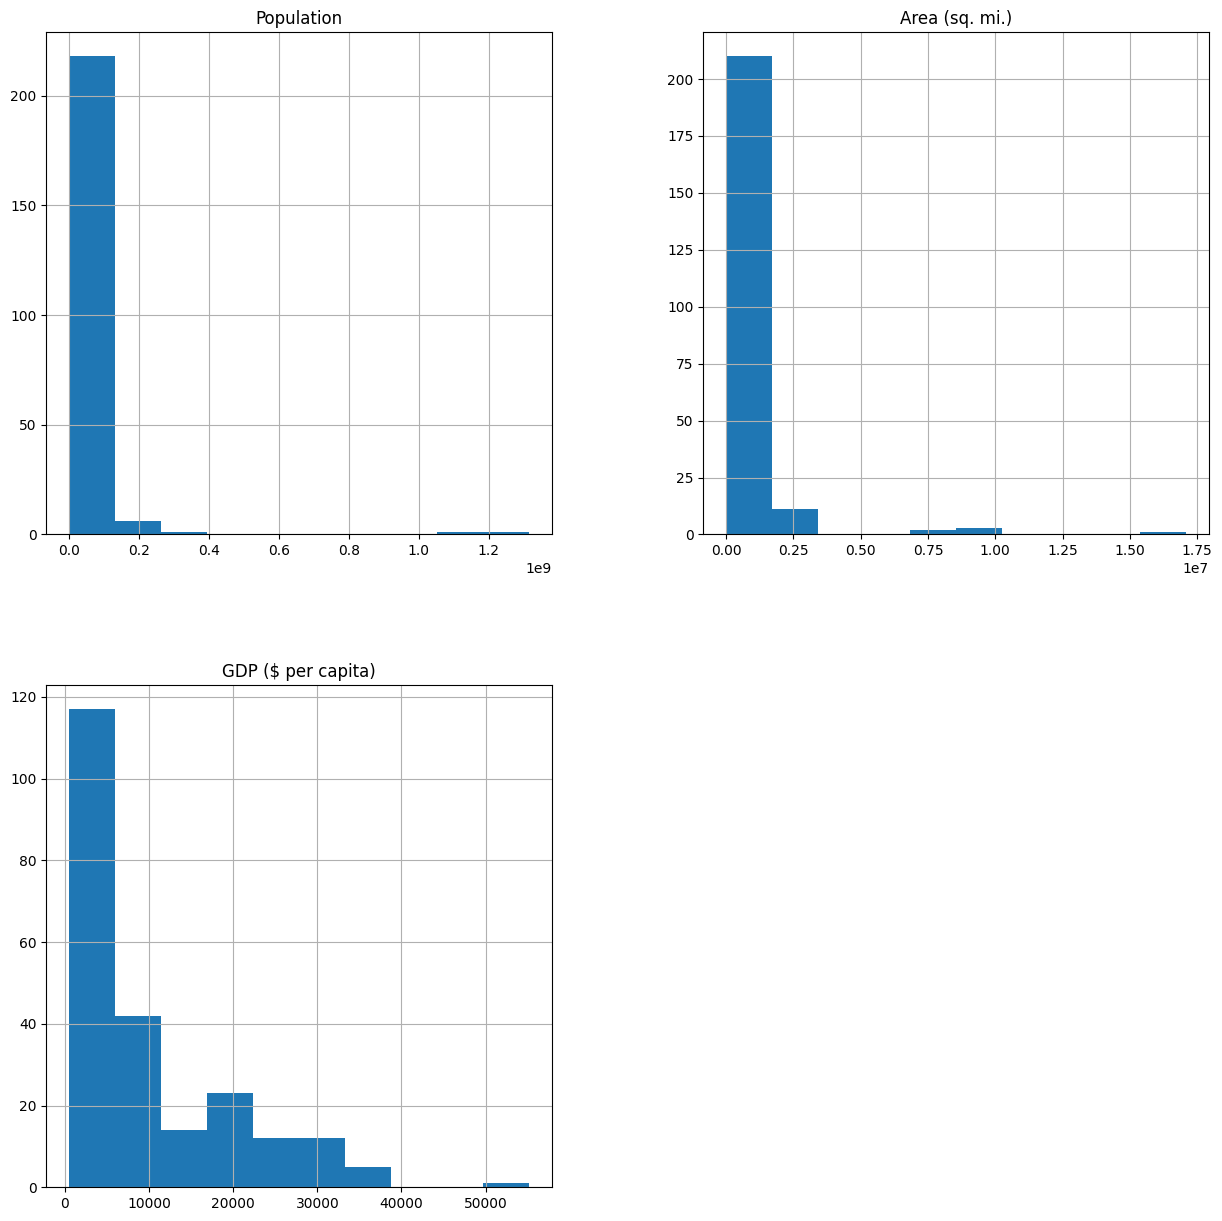

In [ ]:
# Histogram of all numeric fields
df_hist = df.drop(columns=['Literacy (%)'],axis=1)
df_hist.hist(figsize=(15,15));

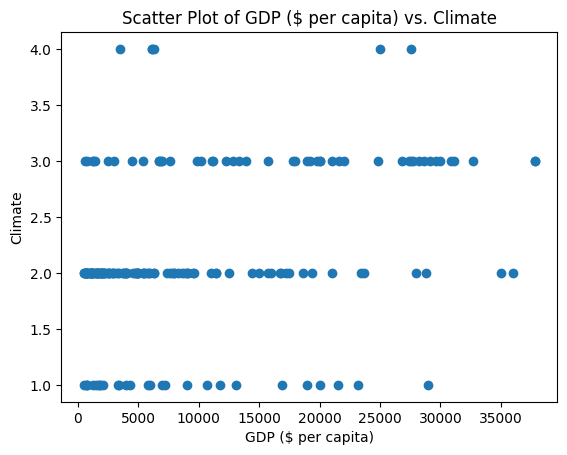

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df1 is your DataFrame
# Convert 'Net migration' and 'Literacy (%)' to numeric
df['GDP ($ per capita)'] = pd.to_numeric(df['GDP ($ per capita)'], errors='coerce')
df['Climate'] = pd.to_numeric(df['Climate'], errors='coerce')

# Visualize the target variable
plt.scatter(df['GDP ($ per capita)'], df['Climate'])
plt.xlabel('GDP ($ per capita)')
plt.ylabel('Climate')
plt.title('Scatter Plot of GDP ($ per capita) vs. Climate')
plt.show()


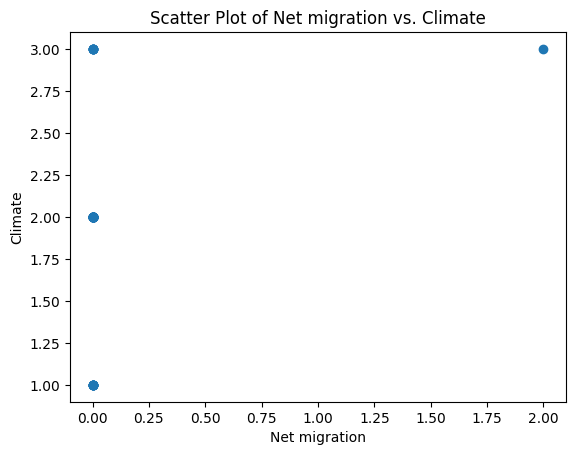

In [ ]:

import matplotlib.pyplot as plt
import pandas as pd

# Assuming df is your DataFrame
# Convert 'Net migration' and 'Literacy (%)' to numeric
df['Net migration'] = pd.to_numeric(df['Net migration'], errors='coerce')
df['Climate'] = pd.to_numeric(df['Climate'], errors='coerce')

# Visualize the target variable
plt.scatter(df['Net migration'], df['Climate'])
plt.xlabel('Net migration')
plt.ylabel('Climate')
plt.title('Scatter Plot of Net migration vs. Climate')
plt.show()


In [ ]:
import pandas as pd

# Convert numeric columns to appropriate types
numeric_columns = ['Population', 'Area (sq. mi.)', 'GDP ($ per capita)']
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Get the absolute correlation values with GDP ($ per capita)
correlation_with_gdp = correlation_matrix['GDP ($ per capita)'].abs().sort_values(ascending=False)

# Display the top N features
top_features_gdp = correlation_with_gdp.head(5)  # You can adjust the number of features you want to consider
print("Top features correlated with GDP ($ per capita):")
print(top_features_gdp)


Top features correlated with GDP ($ per capita):
GDP ($ per capita)    1.000000
Net migration         0.433721
Climate               0.332408
Area (sq. mi.)        0.072185
Population            0.039324
Name: GDP ($ per capita), dtype: float64


<ipython-input-88-7372528a4d4e>:8: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


In [ ]:
import numpy as np

def out_iqr(s, k=1.5, return_thresholds=False):
    """
    Return a boolean mask of outliers for a series
    using interquartile range, works column-wise.
    param k:
        some cutoff to multiply by the iqr
    :type k: ``float``
    param return_thresholds:
        True returns the lower and upper bounds, good for plotting.
        False returns the masked array
    :type return_thresholds: ``bool``
    """
    # Exclude non-numeric values
    numeric_values = pd.to_numeric(s, errors='coerce')

    # Calculate interquartile range
    q25, q75 = np.percentile(numeric_values.dropna(), 25), np.percentile(numeric_values.dropna(), 75)
    iqr = q75 - q25

    # Calculate the outlier cutoff
    cut_off = iqr * k
    lower, upper = q25 - cut_off, q75 + cut_off

    if return_thresholds:
        return lower, upper
    else: # Identify outliers
        return [True if pd.notna(x) and (x < lower or x > upper) else False for x in s]


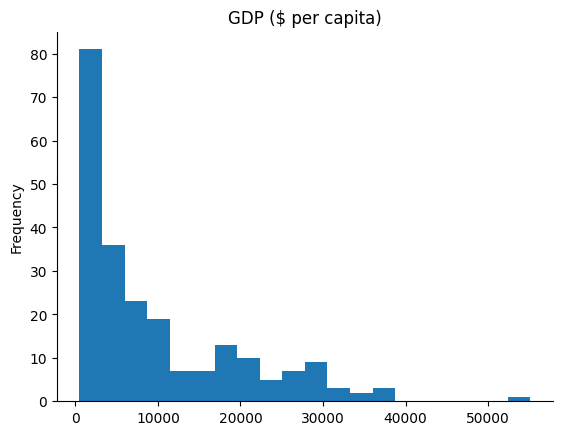

In [ ]:
from matplotlib import pyplot as plt
df['GDP ($ per capita)'].plot(kind='hist', bins=20, title='GDP ($ per capita)')
plt.gca().spines[['top', 'right',]].set_visible(False)

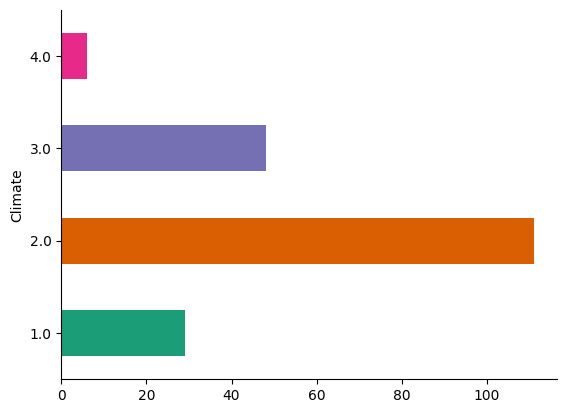

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('Climate').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
df.nunique()

Country                               227
Region                                 11
Population                            227
Area (sq. mi.)                        226
Pop. Density (per sq. mi.)            219
Coastline (coast/area ratio)          151
Net migration                           2
Infant mortality (per 1000 births)    220
GDP ($ per capita)                    130
Literacy (%)                          140
Phones (per 1000)                     214
Arable (%)                            203
Crops (%)                             162
Other (%)                             209
Climate                                 4
Birthrate                             220
Deathrate                             201
Agriculture                           150
Industry                              155
Service                               167
dtype: int64

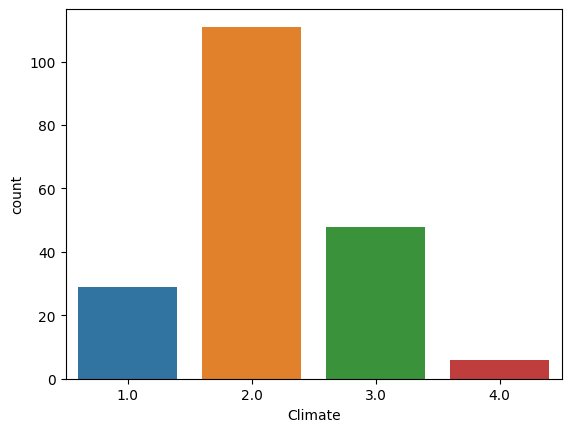

In [ ]:
sns.countplot(x='Climate',data=df)
plt.show()

In [ ]:
#to know the count of each and every region
df.groupby('Region').size()

Region
ASIA (EX. NEAR EAST)                   28
BALTICS                                 3
C.W. OF IND. STATES                    12
EASTERN EUROPE                         12
LATIN AMER. & CARIB                    45
NEAR EAST                              16
NORTHERN AFRICA                         6
NORTHERN AMERICA                        5
OCEANIA                                21
SUB-SAHARAN AFRICA                     51
WESTERN EUROPE                         28
dtype: int64

Text(0.5, 0, 'GDP ($ per capita)')

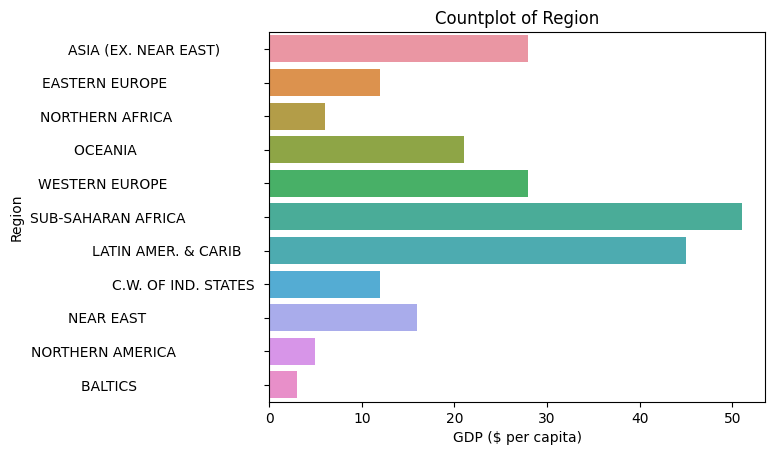

In [ ]:
sns.countplot(y='Region',data=df)
plt.title("Countplot of Region")
plt.ylabel("Region")
plt.xlabel("GDP ($ per capita)")

In [ ]:
df.groupby(['Region'], as_index=False)['GDP ($ per capita)'].mean()



,Region,GDP ($ per capita)
0,ASIA (EX. NEAR EAST),8053.571429
1,BALTICS,11300.000000
2,C.W. OF IND. STATES,4000.000000
3,EASTERN EUROPE,9808.333333
4,LATIN AMER. & CARIB,8682.222222
5,NEAR EAST,10456.250000
6,NORTHERN AFRICA,5460.000000
7,NORTHERN AMERICA,26100.000000
8,OCEANIA,8247.619048
9,SUB-SAHARAN AFRICA,2323.529412


from matplotlib import pyplot as plt
_df_0['GDP ($ per capita)'].plot(kind='hist', bins=20, title='GDP ($ per capita)')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['GDP ($ per capita)'].plot(kind='line', figsize=(8, 4), title='GDP ($ per capita)')
plt.gca().spines[['top', 'right']].set_visible(False)

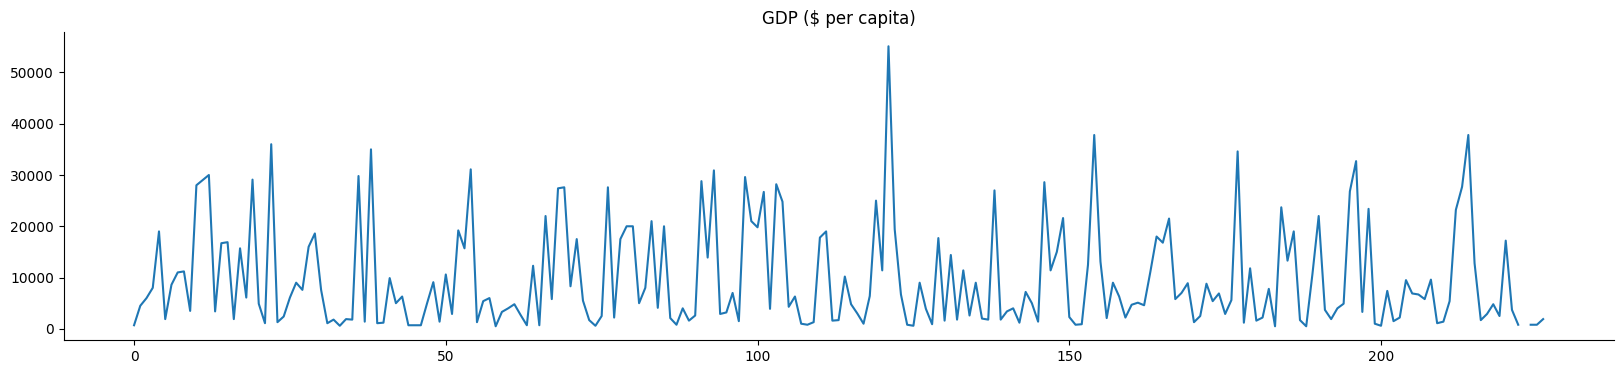

In [ ]:
from matplotlib import pyplot as plt
df['GDP ($ per capita)'].plot(kind='line', figsize=(20, 4), title='GDP ($ per capita)')
plt.gca().spines[['top', 'right']].set_visible(False)

#Tutorial: Time Series Forecasting with Prophet

In [ ]:
pip install fbprophet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.0/64.0 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 20.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 14.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 MB 12.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 84.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 8.3 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for fbprophet


In [ ]:
pip install --upgrade pip


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 12.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 23.1.2
    Uninstalling pip-23.1.2:
      Successfully uninstalled pip-23.1.2


In [ ]:


pip install fbprophet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.0/64.0 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 4.6 MB/s eta 0:00:00
  Using cached PyMeeus-0.5.12-py3-none-any.whl
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 5.1 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for fbprophet
  Running setup.py clean for fbprophet
Failed to build fbprophet
ERROR: Could no